# Task 3: Forecast Future Market Trends

**Objective:** Use the best-performing model (LSTM) from Task 2 to forecast Tesla's future stock prices for 6–12 months, visualize with confidence intervals, and derive actionable market insights.

**Deliverables:**
1. Forecast visualization with confidence intervals
2. Trend analysis summary
3. Identified opportunities and risks
4. Critical assessment of forecast reliability

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
import os

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
processed_dir = os.path.join('..', 'data', 'processed')

print(f"Device: {device}")
print("All imports successful.")

Device: cpu
All imports successful.


In [2]:
close_prices = pd.read_csv(os.path.join(processed_dir, 'close_prices.csv'),
                           index_col=0, parse_dates=True)
tsla_close = close_prices['TSLA'].dropna()

split_date = '2025-01-01'
train = tsla_close[tsla_close.index < split_date]
test = tsla_close[tsla_close.index >= split_date]

print(f"Full series: {tsla_close.index.min().date()} to {tsla_close.index.max().date()} ({len(tsla_close)} days)")
print(f"Train: {len(train)} days | Test: {len(test)} days")
print(f"Last known price: ${tsla_close.iloc[-1]:.2f} on {tsla_close.index[-1].date()}")

Full series: 2015-01-02 to 2026-06-29 (2888 days)
Train: 2516 days | Test: 372 days
Last known price: $411.84 on 2026-06-29


## 2. Rebuild Best-Performing Model (LSTM)

From Task 2, the LSTM model was the clear winner with:
- **MAE:** 9.84 | **RMSE:** 12.65 | **MAPE:** 2.79%

We retrain on all available data to produce the most accurate future forecast.

In [3]:
SEQUENCE_LENGTH = 60

scaler = MinMaxScaler(feature_range=(0, 1))
all_data = tsla_close.values.reshape(-1, 1)
scaled_data = scaler.fit_transform(all_data)

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :])
        out = self.fc(out)
        return out.squeeze()

print(f"Sequence length: {SEQUENCE_LENGTH}")
print(f"Total scaled data points: {len(scaled_data)}")

Sequence length: 60
Total scaled data points: 2888


In [4]:
X_all, y_all = [], []
for i in range(SEQUENCE_LENGTH, len(scaled_data)):
    X_all.append(scaled_data[i - SEQUENCE_LENGTH:i, 0])
    y_all.append(scaled_data[i, 0])

X_all = np.array(X_all).reshape(-1, SEQUENCE_LENGTH, 1)
y_all = np.array(y_all)

train_dataset = StockDataset(X_all, y_all)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

model = LSTMModel(input_size=1, hidden_size=64, num_layers=2, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

EPOCHS = 50
print(f"Training LSTM on ALL data ({len(X_all)} sequences) for {EPOCHS} epochs...")
print(f"{'-'*60}")

train_losses = []
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  Loss: {avg_loss:.6f}  LR: {lr:.6f}")

print(f"{'-'*60}")
print(f"Final training loss: {train_losses[-1]:.6f}")

Training LSTM on ALL data (2828 sequences) for 50 epochs...
------------------------------------------------------------


Epoch [  1/50]  Loss: 0.042731  LR: 0.001000


Epoch [ 10/50]  Loss: 0.001701  LR: 0.001000


Epoch [ 20/50]  Loss: 0.001405  LR: 0.001000


Epoch [ 30/50]  Loss: 0.001053  LR: 0.001000


Epoch [ 40/50]  Loss: 0.000945  LR: 0.000500


Epoch [ 50/50]  Loss: 0.000970  LR: 0.000250
------------------------------------------------------------
Final training loss: 0.000970


## 3. Generate Future Forecasts (6–12 Months)

### 3.1 LSTM Multi-Step Iterative Forecasting

We predict one step at a time and feed each prediction back as input for the next step. To estimate uncertainty, we use **Monte Carlo Dropout** — running multiple forward passes with dropout enabled to produce a distribution of forecasts.

In [5]:
FORECAST_DAYS = 252  # ~12 months of trading days
N_SIMULATIONS = 100  # Monte Carlo simulations for confidence intervals

def enable_mc_dropout(model):
    """Enable dropout at inference time for Monte Carlo estimation."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

def lstm_iterative_forecast(model, seed_sequence, n_steps, scaler, mc_dropout=False):
    """Generate multi-step forecast by feeding predictions back."""
    if mc_dropout:
        model.eval()
        enable_mc_dropout(model)
    else:
        model.eval()

    current_seq = seed_sequence.copy()
    predictions = []

    with torch.no_grad():
        for _ in range(n_steps):
            x = torch.FloatTensor(current_seq.reshape(1, -1, 1)).to(device)
            pred_scaled = model(x).cpu().numpy().item()
            predictions.append(pred_scaled)
            current_seq = np.append(current_seq[1:], pred_scaled)

    predictions = np.array(predictions).reshape(-1, 1)
    predictions_actual = scaler.inverse_transform(predictions).flatten()
    return predictions_actual

seed_seq = scaled_data[-SEQUENCE_LENGTH:, 0]

print(f"Running {N_SIMULATIONS} Monte Carlo simulations for {FORECAST_DAYS} trading days...")
mc_forecasts = []
for i in range(N_SIMULATIONS):
    forecast = lstm_iterative_forecast(model, seed_seq, FORECAST_DAYS, scaler, mc_dropout=True)
    mc_forecasts.append(forecast)
    if (i + 1) % 25 == 0:
        print(f"  Completed {i+1}/{N_SIMULATIONS} simulations")

mc_forecasts = np.array(mc_forecasts)
print(f"\nMC forecast array shape: {mc_forecasts.shape}")

# Also generate deterministic forecast (no dropout)
model.eval()
deterministic_forecast = lstm_iterative_forecast(model, seed_seq, FORECAST_DAYS, scaler, mc_dropout=False)
print(f"Deterministic forecast generated: {len(deterministic_forecast)} steps")

Running 100 Monte Carlo simulations for 252 trading days...


  Completed 25/100 simulations


  Completed 50/100 simulations


  Completed 75/100 simulations


  Completed 100/100 simulations

MC forecast array shape: (100, 252)


Deterministic forecast generated: 252 steps


In [6]:
# Compute forecast statistics
forecast_mean = mc_forecasts.mean(axis=0)
forecast_median = np.median(mc_forecasts, axis=0)
forecast_std = mc_forecasts.std(axis=0)
ci_90_lower = np.percentile(mc_forecasts, 5, axis=0)
ci_90_upper = np.percentile(mc_forecasts, 95, axis=0)
ci_50_lower = np.percentile(mc_forecasts, 25, axis=0)
ci_50_upper = np.percentile(mc_forecasts, 75, axis=0)

# Generate future dates (business days)
last_date = tsla_close.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

print(f"Forecast period: {future_dates[0].date()} to {future_dates[-1].date()}")
print(f"\nForecast summary (mean path):")
print(f"  Starting price:  ${forecast_mean[0]:.2f}")
print(f"  3-month price:   ${forecast_mean[62]:.2f}")
print(f"  6-month price:   ${forecast_mean[125]:.2f}")
print(f"  12-month price:  ${forecast_mean[-1]:.2f}")
print(f"\n90% CI width at:")
print(f"  1 month:  ${ci_90_upper[21] - ci_90_lower[21]:.2f}")
print(f"  3 months: ${ci_90_upper[62] - ci_90_lower[62]:.2f}")
print(f"  6 months: ${ci_90_upper[125] - ci_90_lower[125]:.2f}")
print(f"  12 months: ${ci_90_upper[-1] - ci_90_lower[-1]:.2f}")

Forecast period: 2026-06-30 to 2027-06-16

Forecast summary (mean path):
  Starting price:  $393.90
  3-month price:   $392.53
  6-month price:   $385.63
  12-month price:  $385.40

90% CI width at:
  1 month:  $134.44
  3 months: $140.14
  6 months: $186.04
  12 months: $160.69


### 3.2 SARIMA Forecast with Native Confidence Intervals

We also generate a SARIMA forecast to provide a complementary statistical perspective with built-in confidence intervals.

In [7]:
print("Fitting SARIMA(0,1,0)(2,0,2,5) on full dataset for future forecast...")
sarima_model = SARIMAX(tsla_close, order=(0, 1, 0), seasonal_order=(2, 0, 2, 5))
sarima_fitted = sarima_model.fit(disp=False)

sarima_future = sarima_fitted.get_forecast(steps=FORECAST_DAYS)
sarima_forecast_mean = sarima_future.predicted_mean
sarima_ci = sarima_future.conf_int(alpha=0.10)  # 90% CI

sarima_forecast_mean.index = future_dates[:len(sarima_forecast_mean)]
sarima_ci.index = future_dates[:len(sarima_ci)]

print(f"SARIMA forecast complete.")
print(f"  12-month forecast: ${sarima_forecast_mean.iloc[-1]:.2f}")
print(f"  90% CI at 12 months: [${sarima_ci.iloc[-1, 0]:.2f}, ${sarima_ci.iloc[-1, 1]:.2f}]")

Fitting SARIMA(0,1,0)(2,0,2,5) on full dataset for future forecast...


SARIMA forecast complete.
  12-month forecast: $409.22
  90% CI at 12 months: [$225.68, $592.76]


## 4. Forecast Visualization with Confidence Intervals

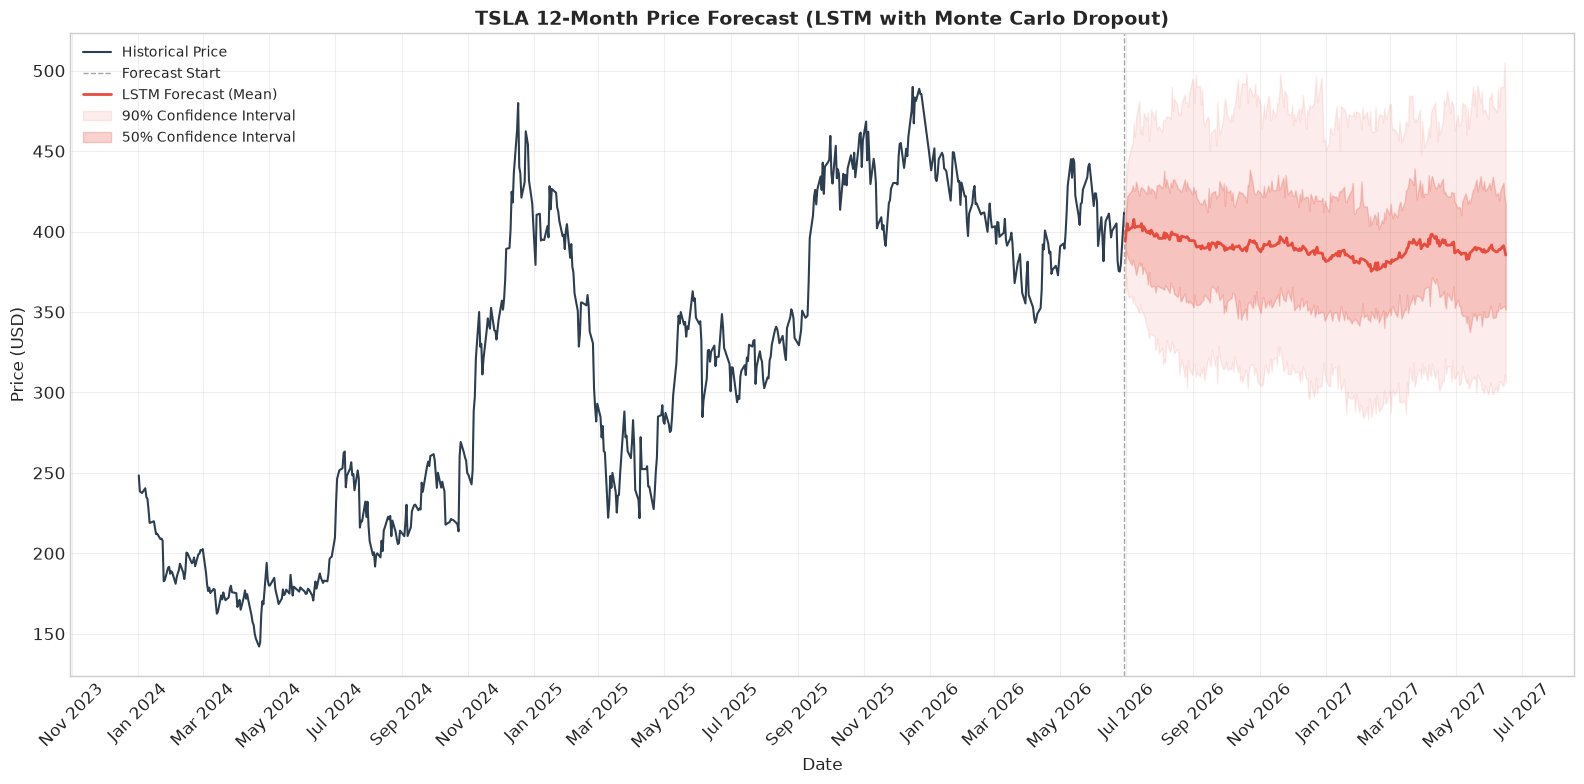

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))

# Historical data (last 2 years for context)
hist_start = '2024-01-01'
hist_data = tsla_close[tsla_close.index >= hist_start]
ax.plot(hist_data.index, hist_data.values, color='#2c3e50', linewidth=1.5, label='Historical Price')

# Vertical line at forecast start
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Forecast Start')

# LSTM forecast
ax.plot(future_dates, forecast_mean, color='#e74c3c', linewidth=2, label='LSTM Forecast (Mean)')
ax.fill_between(future_dates, ci_90_lower, ci_90_upper,
                color='#e74c3c', alpha=0.1, label='90% Confidence Interval')
ax.fill_between(future_dates, ci_50_lower, ci_50_upper,
                color='#e74c3c', alpha=0.25, label='50% Confidence Interval')

ax.set_title('TSLA 12-Month Price Forecast (LSTM with Monte Carlo Dropout)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'lstm_future_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

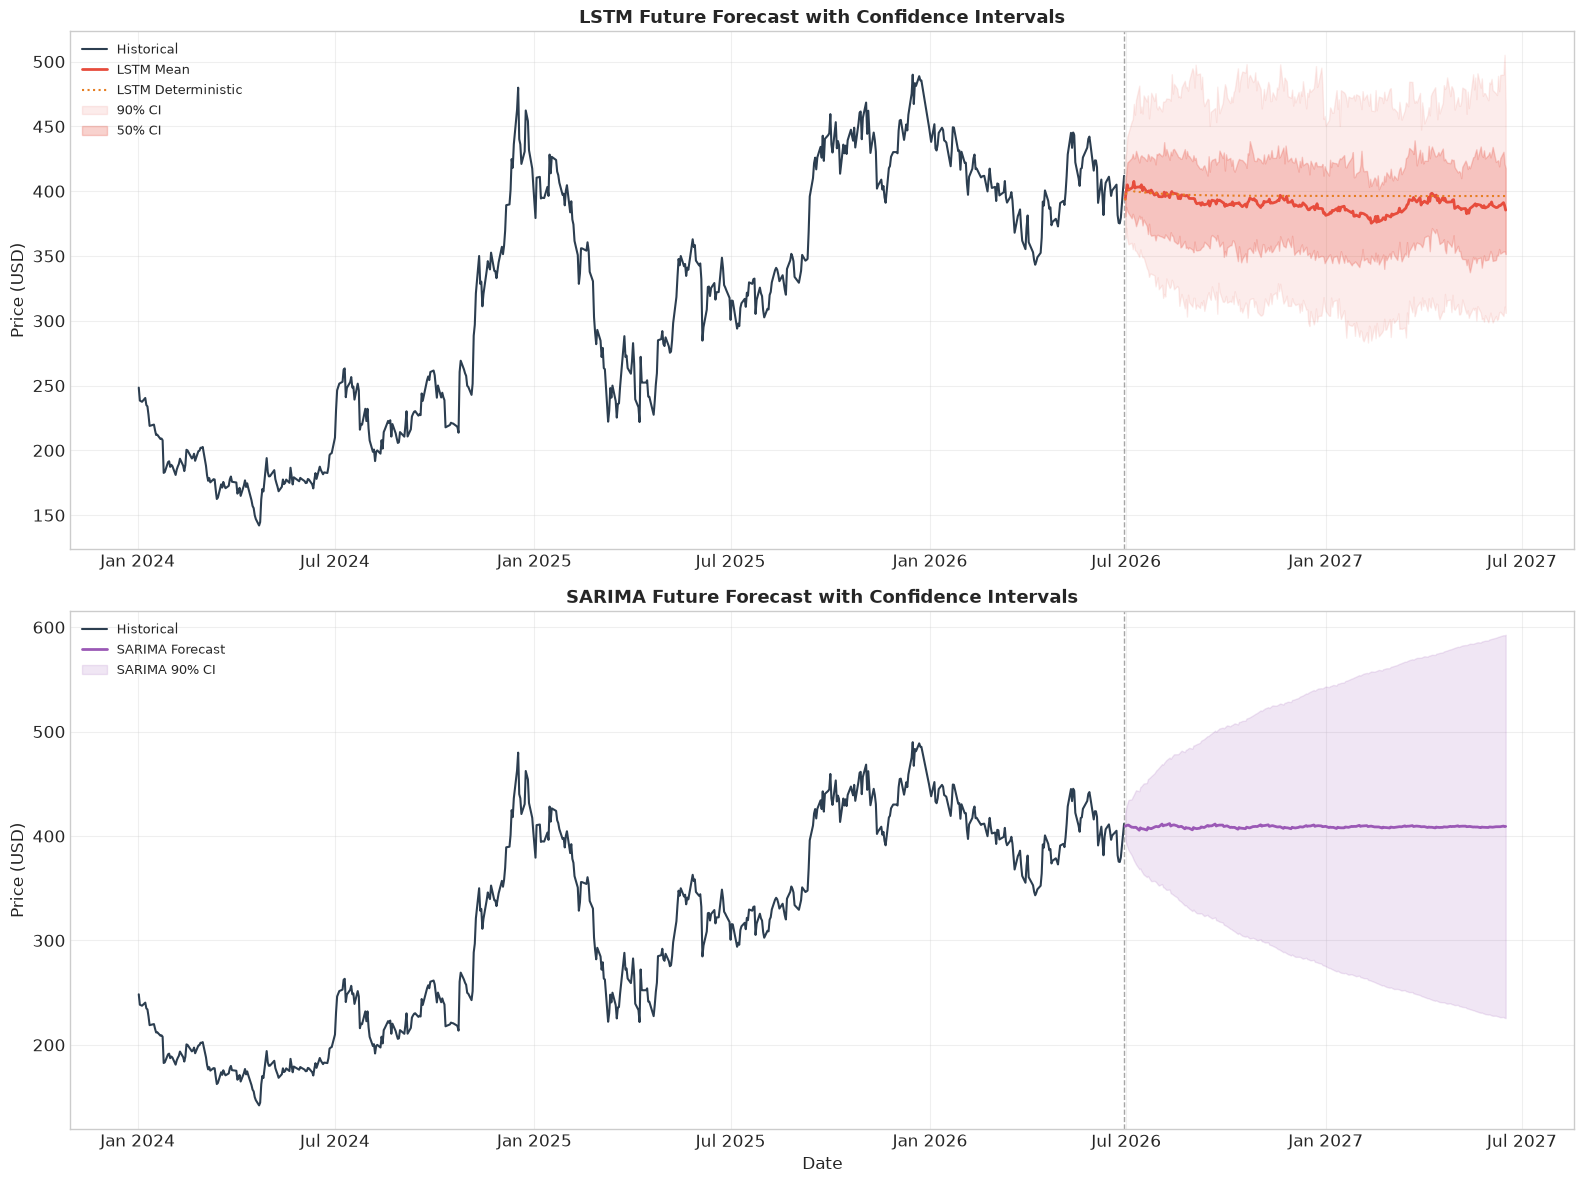

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- LSTM Forecast ---
ax = axes[0]
hist_data = tsla_close[tsla_close.index >= hist_start]
ax.plot(hist_data.index, hist_data.values, color='#2c3e50', linewidth=1.5, label='Historical')
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(future_dates, forecast_mean, color='#e74c3c', linewidth=2, label='LSTM Mean')
ax.plot(future_dates, deterministic_forecast, color='#e67e22', linewidth=1.5,
        linestyle=':', label='LSTM Deterministic')
ax.fill_between(future_dates, ci_90_lower, ci_90_upper, color='#e74c3c', alpha=0.1, label='90% CI')
ax.fill_between(future_dates, ci_50_lower, ci_50_upper, color='#e74c3c', alpha=0.25, label='50% CI')
ax.set_title('LSTM Future Forecast with Confidence Intervals', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# --- SARIMA Forecast ---
ax = axes[1]
ax.plot(hist_data.index, hist_data.values, color='#2c3e50', linewidth=1.5, label='Historical')
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.plot(sarima_forecast_mean.index, sarima_forecast_mean.values,
        color='#9b59b6', linewidth=2, label='SARIMA Forecast')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                color='#9b59b6', alpha=0.15, label='SARIMA 90% CI')
ax.set_title('SARIMA Future Forecast with Confidence Intervals', fontsize=13, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'combined_future_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()

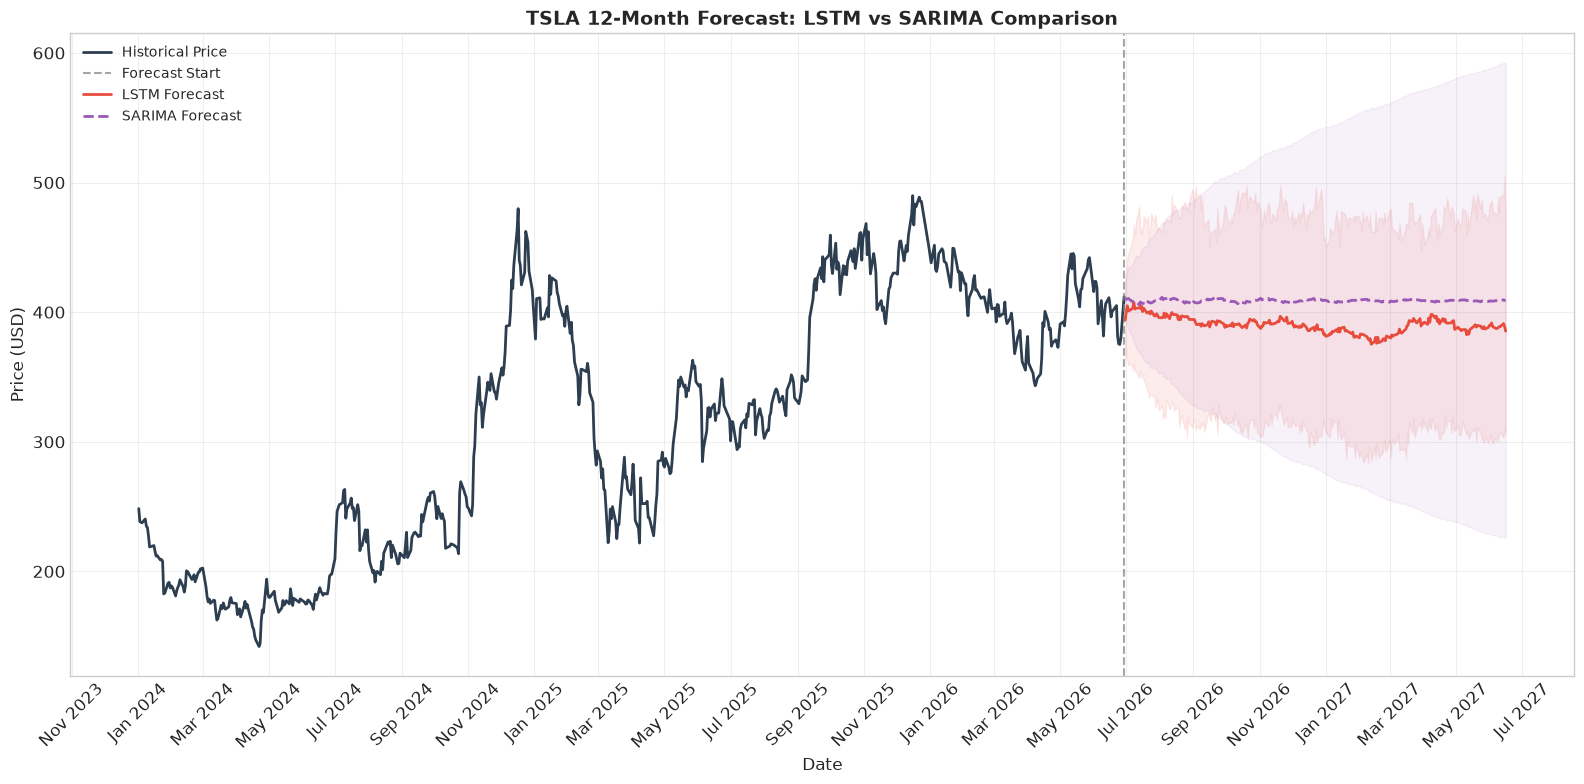

In [10]:
# Combined overlay for direct comparison
fig, ax = plt.subplots(figsize=(16, 8))

hist_data = tsla_close[tsla_close.index >= hist_start]
ax.plot(hist_data.index, hist_data.values, color='#2c3e50', linewidth=2, label='Historical Price')

# Test period predictions (LSTM from Task 2 context)
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='Forecast Start')

# LSTM
ax.plot(future_dates, forecast_mean, color='#e74c3c', linewidth=2, label='LSTM Forecast')
ax.fill_between(future_dates, ci_90_lower, ci_90_upper, color='#e74c3c', alpha=0.1)

# SARIMA
ax.plot(sarima_forecast_mean.index, sarima_forecast_mean.values,
        color='#9b59b6', linewidth=2, linestyle='--', label='SARIMA Forecast')
ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                color='#9b59b6', alpha=0.08)

ax.set_title('TSLA 12-Month Forecast: LSTM vs SARIMA Comparison',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'forecast_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Trend Analysis

In [11]:
# Monthly forecast summary
months = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 251]
month_labels = ['1M', '2M', '3M', '4M', '5M', '6M', '7M', '8M', '9M', '10M', '11M', '12M']

print("=" * 90)
print("MONTHLY FORECAST SUMMARY (LSTM)")
print("=" * 90)
print(f"{'Horizon':<8} {'Date':<12} {'Mean Price':<12} {'90% CI Lower':<14} {'90% CI Upper':<14} {'CI Width':<12} {'CI %':<8}")
print("-" * 90)

last_price = tsla_close.iloc[-1]
for m, label in zip(months, month_labels):
    idx = min(m, len(forecast_mean) - 1)
    mean_p = forecast_mean[idx]
    lo = ci_90_lower[idx]
    hi = ci_90_upper[idx]
    width = hi - lo
    ci_pct = (width / mean_p) * 100
    date_str = future_dates[idx].strftime('%Y-%m-%d')
    print(f"{label:<8} {date_str:<12} ${mean_p:>9.2f}   ${lo:>10.2f}     ${hi:>10.2f}     ${width:>8.2f}    {ci_pct:>5.1f}%")

print("-" * 90)
print(f"\nLast known price: ${last_price:.2f}")
change_6m = ((forecast_mean[125] - last_price) / last_price) * 100
change_12m = ((forecast_mean[-1] - last_price) / last_price) * 100
print(f"Forecasted 6-month change: {change_6m:+.1f}%")
print(f"Forecasted 12-month change: {change_12m:+.1f}%")

MONTHLY FORECAST SUMMARY (LSTM)
Horizon  Date         Mean Price   90% CI Lower   90% CI Upper   CI Width     CI %    
------------------------------------------------------------------------------------------
1M       2026-07-29   $   398.74   $    330.28     $    464.72     $  134.44     33.7%
2M       2026-08-27   $   396.12   $    320.13     $    477.55     $  157.42     39.7%
3M       2026-09-25   $   393.12   $    322.53     $    460.15     $  137.62     35.0%
4M       2026-10-26   $   393.23   $    317.46     $    484.16     $  166.71     42.4%
5M       2026-11-24   $   393.06   $    314.91     $    487.63     $  172.73     43.9%
6M       2026-12-23   $   388.00   $    309.57     $    496.56     $  186.99     48.2%
7M       2027-01-21   $   385.36   $    300.17     $    465.22     $  165.06     42.8%
8M       2027-02-19   $   376.50   $    288.00     $    472.95     $  184.96     49.1%
9M       2027-03-22   $   392.74   $    306.53     $    484.29     $  177.75     45.3%
10M    

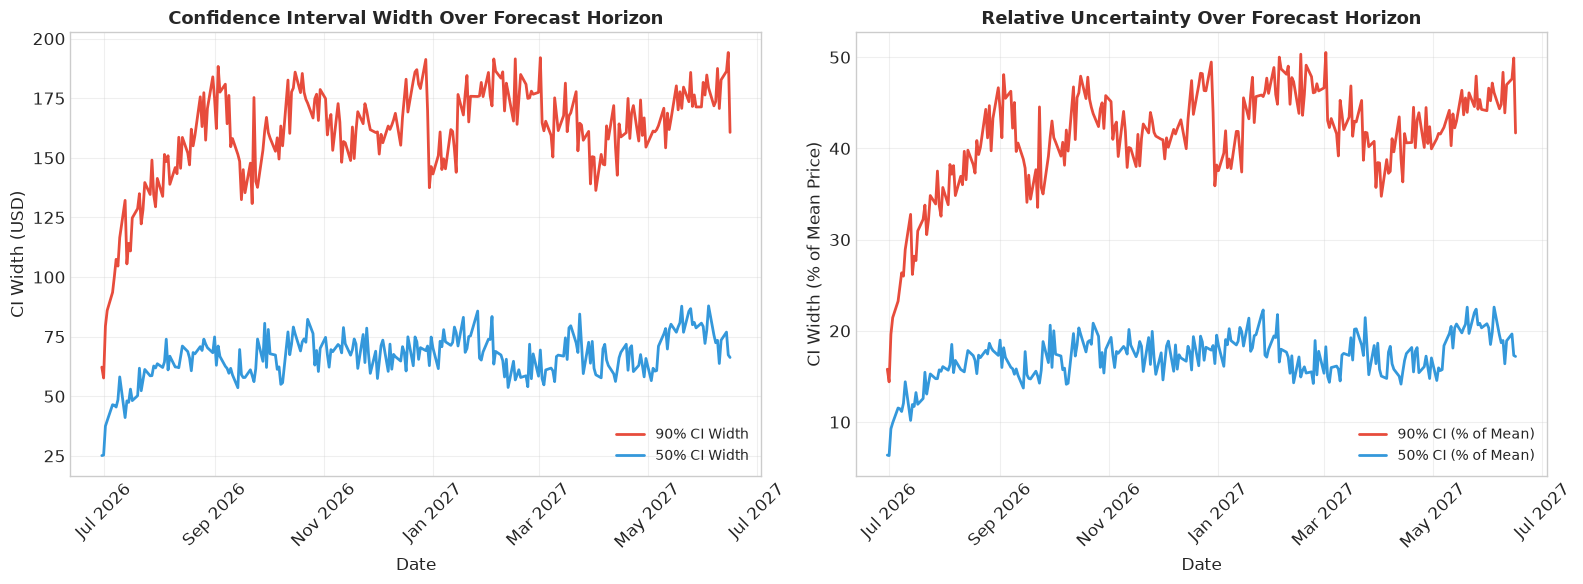

In [12]:
# Confidence interval width over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CI width growth
ci_width_90 = ci_90_upper - ci_90_lower
ci_width_50 = ci_50_upper - ci_50_lower

axes[0].plot(future_dates, ci_width_90, color='#e74c3c', linewidth=2, label='90% CI Width')
axes[0].plot(future_dates, ci_width_50, color='#3498db', linewidth=2, label='50% CI Width')
axes[0].set_title('Confidence Interval Width Over Forecast Horizon', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('CI Width (USD)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Relative CI width (as % of mean)
ci_pct_90 = (ci_width_90 / forecast_mean) * 100
ci_pct_50 = (ci_width_50 / forecast_mean) * 100

axes[1].plot(future_dates, ci_pct_90, color='#e74c3c', linewidth=2, label='90% CI (% of Mean)')
axes[1].plot(future_dates, ci_pct_50, color='#3498db', linewidth=2, label='50% CI (% of Mean)')
axes[1].set_title('Relative Uncertainty Over Forecast Horizon', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('CI Width (% of Mean Price)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'ci_width_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

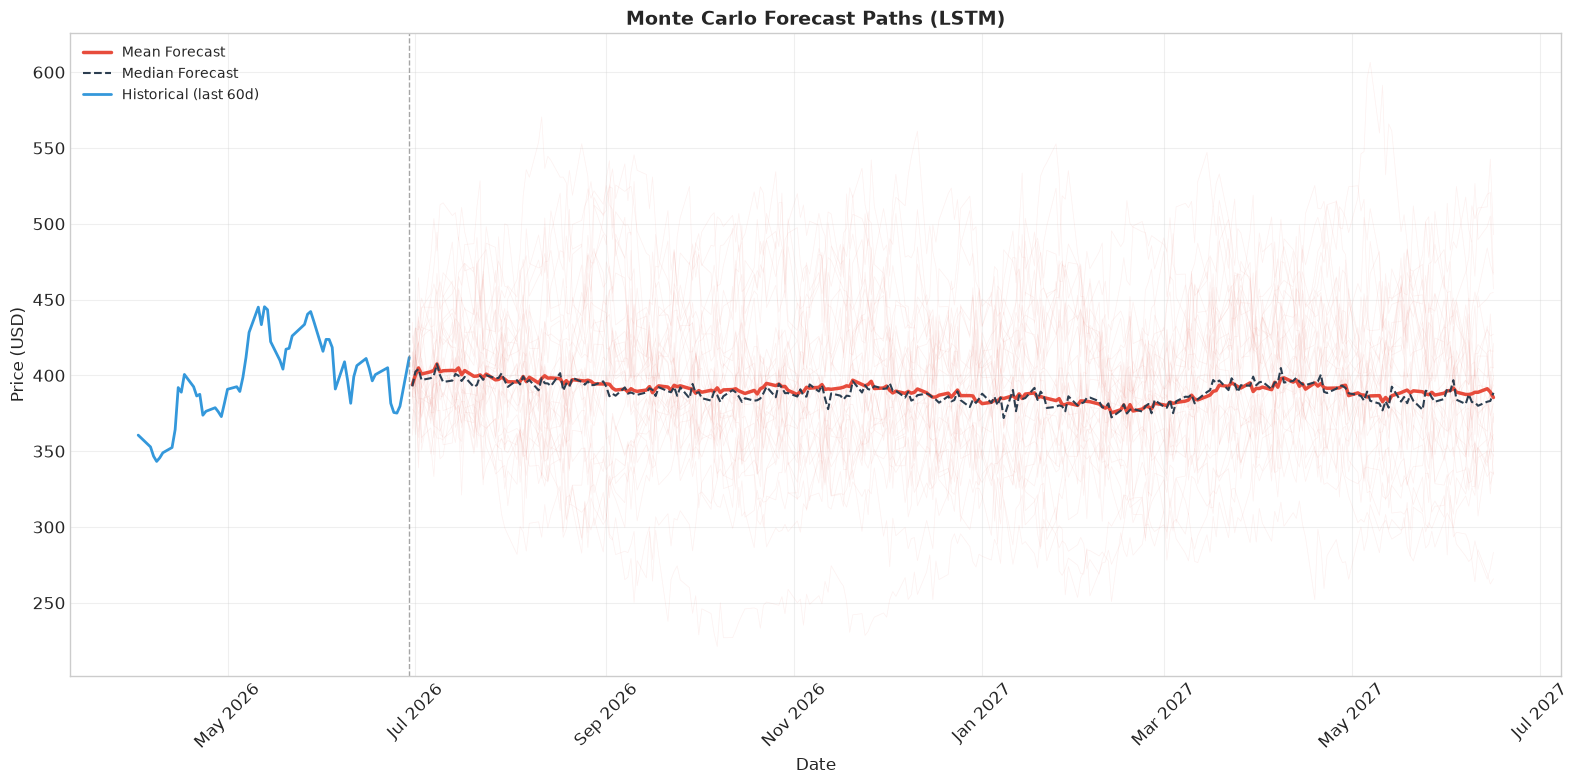

In [13]:
# Monte Carlo forecast fan chart - showing individual paths
fig, ax = plt.subplots(figsize=(16, 8))

# Plot a sample of individual MC paths
n_show = min(30, N_SIMULATIONS)
for i in range(n_show):
    ax.plot(future_dates, mc_forecasts[i], color='#e74c3c', alpha=0.08, linewidth=0.5)

ax.plot(future_dates, forecast_mean, color='#e74c3c', linewidth=2.5, label='Mean Forecast')
ax.plot(future_dates, forecast_median, color='#2c3e50', linewidth=1.5,
        linestyle='--', label='Median Forecast')

# Historical context
hist_60d = tsla_close[-60:]
ax.plot(hist_60d.index, hist_60d.values, color='#3498db', linewidth=2, label='Historical (last 60d)')
ax.axvline(x=last_date, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Monte Carlo Forecast Paths (LSTM)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'mc_paths.png'), dpi=150, bbox_inches='tight')
plt.show()

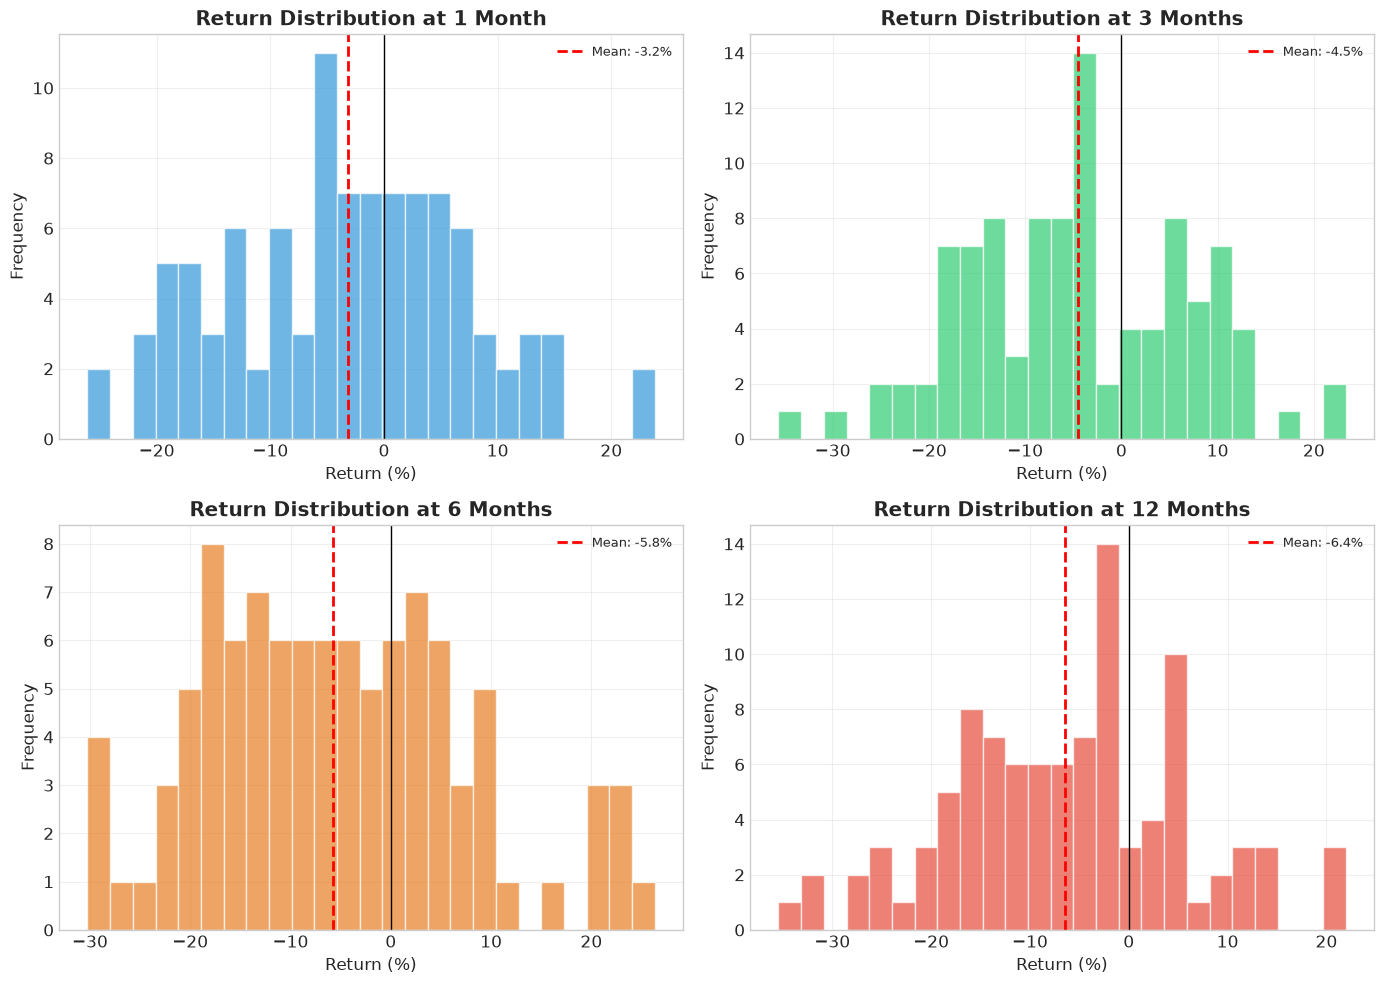

In [14]:
# Forecast return distribution at key horizons
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

horizons = [(21, '1 Month'), (63, '3 Months'), (126, '6 Months'), (251, '12 Months')]
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c']

for ax, (idx, title), color in zip(axes.flat, horizons, colors):
    idx = min(idx, mc_forecasts.shape[1] - 1)
    prices = mc_forecasts[:, idx]
    returns = ((prices - last_price) / last_price) * 100

    ax.hist(returns, bins=25, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(x=np.mean(returns), color='red', linewidth=2, linestyle='--',
              label=f'Mean: {np.mean(returns):+.1f}%')
    ax.axvline(x=0, color='black', linewidth=1, linestyle='-')
    ax.set_title(f'Return Distribution at {title}', fontweight='bold')
    ax.set_xlabel('Return (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'forecast_return_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Trend Analysis Summary

In [15]:
# Compute trend metrics
forecast_returns = np.diff(forecast_mean) / forecast_mean[:-1] * 100
rolling_vol = pd.Series(forecast_returns).rolling(21).std() * np.sqrt(252)

# Price momentum (slope of linear fit in segments)
from numpy.polynomial import polynomial as P

x_full = np.arange(len(forecast_mean))
coefs_full = P.polyfit(x_full, forecast_mean, 1)
daily_trend = coefs_full[1]
annualized_trend = daily_trend * 252

# Short-term vs long-term trend
coefs_3m = P.polyfit(x_full[:63], forecast_mean[:63], 1)
coefs_6m = P.polyfit(x_full[:126], forecast_mean[:126], 1)

print("=" * 70)
print("TREND ANALYSIS")
print("=" * 70)
print(f"\nOverall Trend Direction: {'Upward' if daily_trend > 0 else 'Downward' if daily_trend < 0 else 'Flat'}")
print(f"  Daily trend slope: ${daily_trend:.3f}/day")
print(f"  Annualized trend: ${annualized_trend:.2f}/year")
print(f"\nShort-term (3M) trend slope: ${coefs_3m[1]:.3f}/day")
print(f"Mid-term (6M) trend slope:   ${coefs_6m[1]:.3f}/day")
print(f"Full (12M) trend slope:      ${coefs_full[1]:.3f}/day")

# Probability metrics
prob_above_current = (mc_forecasts[:, -1] > last_price).mean() * 100
prob_above_500 = (mc_forecasts[:, -1] > 500).mean() * 100
prob_below_300 = (mc_forecasts[:, -1] < 300).mean() * 100

print(f"\nProbability Analysis (at 12 months):")
print(f"  P(price > ${last_price:.0f} current): {prob_above_current:.1f}%")
print(f"  P(price > $500): {prob_above_500:.1f}%")
print(f"  P(price < $300): {prob_below_300:.1f}%")

# Max drawdown from starting price in forecast
max_dd_paths = []
for path in mc_forecasts:
    peak = path[0]
    max_dd = 0
    for p in path:
        if p > peak:
            peak = p
        dd = (peak - p) / peak * 100
        if dd > max_dd:
            max_dd = dd
    max_dd_paths.append(max_dd)

print(f"\nMax Drawdown Analysis (across MC paths):")
print(f"  Mean max drawdown: {np.mean(max_dd_paths):.1f}%")
print(f"  Worst-case max drawdown: {np.max(max_dd_paths):.1f}%")
print(f"  P(max drawdown > 20%): {(np.array(max_dd_paths) > 20).mean() * 100:.1f}%")

TREND ANALYSIS

Overall Trend Direction: Downward
  Daily trend slope: $-0.045/day
  Annualized trend: $-11.43/year

Short-term (3M) trend slope: $-0.210/day
Mid-term (6M) trend slope:   $-0.102/day
Full (12M) trend slope:      $-0.045/day

Probability Analysis (at 12 months):
  P(price > $412 current): 28.0%
  P(price > $500): 1.0%
  P(price < $300): 4.0%

Max Drawdown Analysis (across MC paths):
  Mean max drawdown: 39.5%
  Worst-case max drawdown: 56.0%
  P(max drawdown > 20%): 100.0%


### Trend Analysis Summary

The following analysis is based on the LSTM model's Monte Carlo forecast paths.

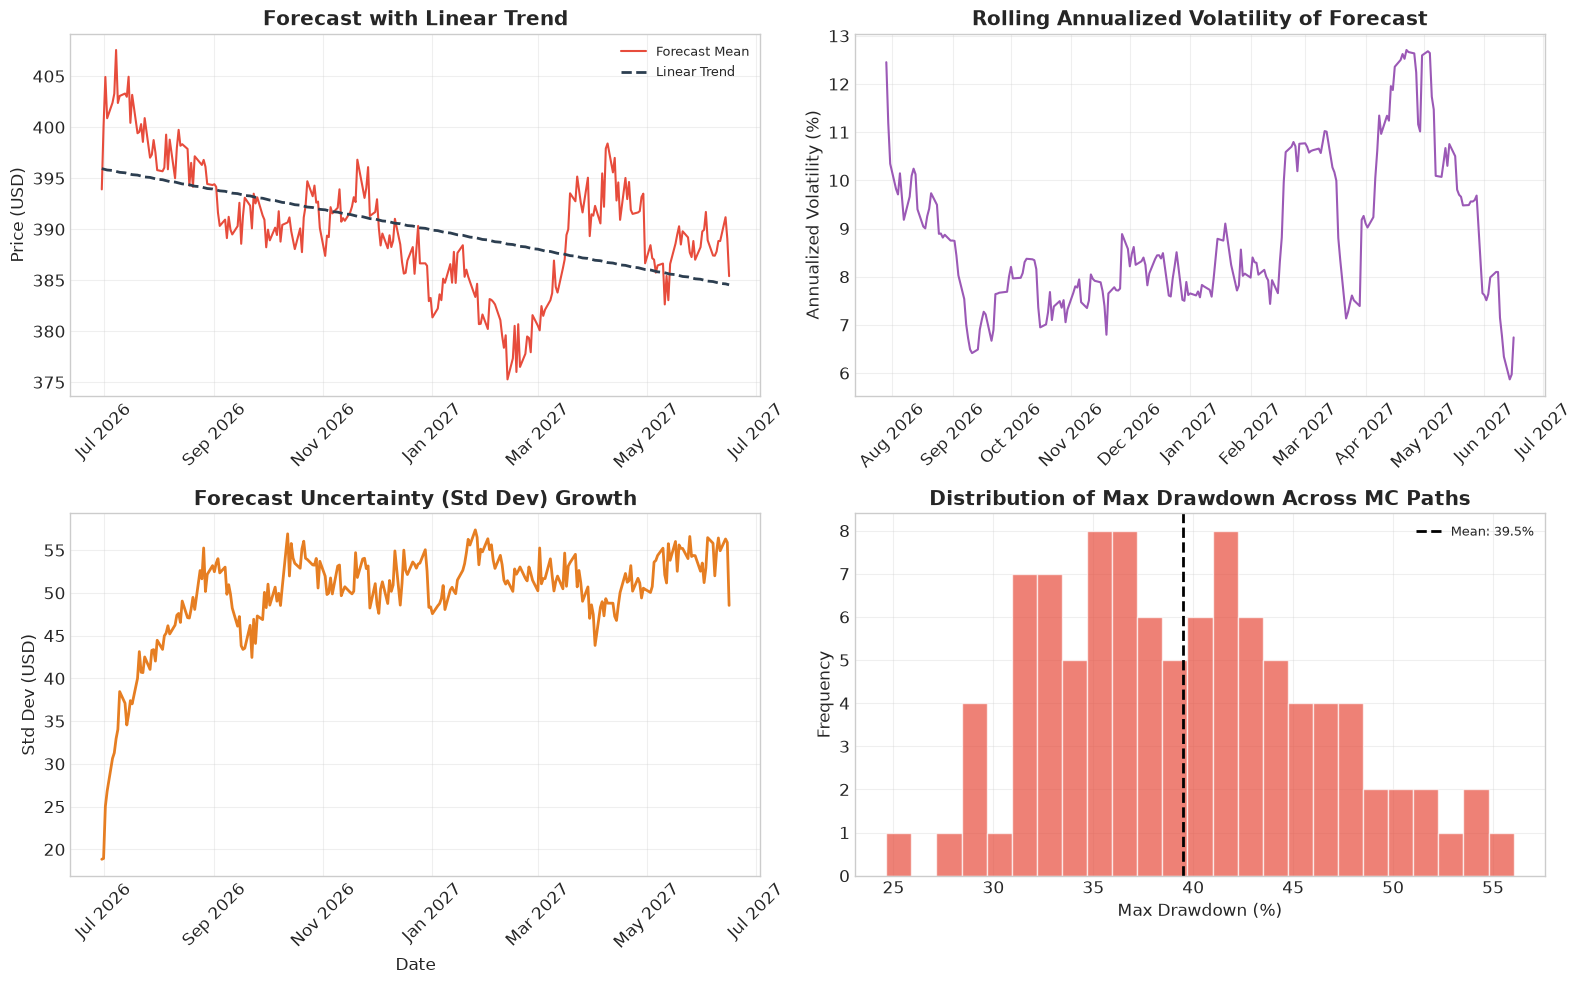

In [16]:
# Trend visualization with linear fit
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Forecast with trend line
ax = axes[0, 0]
ax.plot(future_dates, forecast_mean, color='#e74c3c', linewidth=1.5, label='Forecast Mean')
trend_line = P.polyval(x_full, coefs_full)
ax.plot(future_dates, trend_line, color='#2c3e50', linewidth=2, linestyle='--', label='Linear Trend')
ax.set_title('Forecast with Linear Trend', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 2. Rolling volatility of forecast
ax = axes[0, 1]
ax.plot(future_dates[21:], rolling_vol.dropna().values, color='#9b59b6', linewidth=1.5)
ax.set_title('Rolling Annualized Volatility of Forecast', fontweight='bold')
ax.set_ylabel('Annualized Volatility (%)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 3. Forecast standard deviation growth
ax = axes[1, 0]
ax.plot(future_dates, forecast_std, color='#e67e22', linewidth=2)
ax.set_title('Forecast Uncertainty (Std Dev) Growth', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Std Dev (USD)')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 4. Max drawdown distribution
ax = axes[1, 1]
ax.hist(max_dd_paths, bins=25, color='#e74c3c', alpha=0.7, edgecolor='white')
ax.axvline(x=np.mean(max_dd_paths), color='black', linewidth=2, linestyle='--',
          label=f'Mean: {np.mean(max_dd_paths):.1f}%')
ax.set_title('Distribution of Max Drawdown Across MC Paths', fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'trend_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Market Opportunities and Risks Assessment

In [17]:
# Compute key risk/opportunity metrics
last_price = tsla_close.iloc[-1]

# Expected returns at different horizons
returns_3m = ((mc_forecasts[:, 62] - last_price) / last_price) * 100
returns_6m = ((mc_forecasts[:, 125] - last_price) / last_price) * 100
returns_12m = ((mc_forecasts[:, -1] - last_price) / last_price) * 100

# Sharpe-like ratio (annualized)
risk_free_rate = 4.5  # approximate current risk-free rate
ann_return_12m = np.mean(returns_12m)
ann_vol_12m = np.std(returns_12m)
forecast_sharpe = (ann_return_12m - risk_free_rate) / ann_vol_12m if ann_vol_12m > 0 else 0

# Value at Risk (VaR)
var_95 = np.percentile(returns_12m, 5)
var_99 = np.percentile(returns_12m, 1)
cvar_95 = returns_12m[returns_12m <= var_95].mean()

print("=" * 70)
print("MARKET OPPORTUNITIES AND RISKS ASSESSMENT")
print("=" * 70)

print(f"\n{'='*70}")
print("OPPORTUNITIES")
print(f"{'='*70}")
print(f"  1. Expected Return (Mean):")
print(f"     3-month:  {np.mean(returns_3m):+.1f}%  (${forecast_mean[62]:.2f})")
print(f"     6-month:  {np.mean(returns_6m):+.1f}%  (${forecast_mean[125]:.2f})")
print(f"     12-month: {np.mean(returns_12m):+.1f}%  (${forecast_mean[-1]:.2f})")
print(f"  2. Upside Potential (95th percentile):")
print(f"     12-month: {np.percentile(returns_12m, 95):+.1f}%  (${np.percentile(mc_forecasts[:, -1], 95):.2f})")
print(f"  3. Probability of positive return:")
print(f"     3-month:  {(returns_3m > 0).mean() * 100:.1f}%")
print(f"     6-month:  {(returns_6m > 0).mean() * 100:.1f}%")
print(f"     12-month: {(returns_12m > 0).mean() * 100:.1f}%")

print(f"\n{'='*70}")
print("RISKS")
print(f"{'='*70}")
print(f"  1. Downside Risk (5th percentile):")
print(f"     12-month: {np.percentile(returns_12m, 5):+.1f}%  (${np.percentile(mc_forecasts[:, -1], 5):.2f})")
print(f"  2. Value at Risk (VaR):")
print(f"     95% VaR:  {var_95:+.1f}%")
print(f"     99% VaR:  {var_99:+.1f}%")
print(f"     95% CVaR: {cvar_95:+.1f}%")
print(f"  3. Forecast Sharpe Ratio: {forecast_sharpe:.2f}")
print(f"  4. Max Drawdown Risk:")
print(f"     Mean: {np.mean(max_dd_paths):.1f}%  |  Worst: {np.max(max_dd_paths):.1f}%")
print(f"  5. Volatility of returns: {ann_vol_12m:.1f}%")

MARKET OPPORTUNITIES AND RISKS ASSESSMENT

OPPORTUNITIES
  1. Expected Return (Mean):
     3-month:  -4.7%  ($392.53)
     6-month:  -6.4%  ($385.63)
     12-month: -6.4%  ($385.40)
  2. Upside Potential (95th percentile):
     12-month: +13.3%  ($466.76)
  3. Probability of positive return:
     3-month:  31.0%
     6-month:  29.0%
     12-month: 28.0%

RISKS
  1. Downside Risk (5th percentile):
     12-month: -25.7%  ($306.08)
  2. Value at Risk (VaR):
     95% VaR:  -25.7%
     99% VaR:  -31.4%
     95% CVaR: -30.4%
  3. Forecast Sharpe Ratio: -0.93
  4. Max Drawdown Risk:
     Mean: 39.5%  |  Worst: 56.0%
  5. Volatility of returns: 11.8%


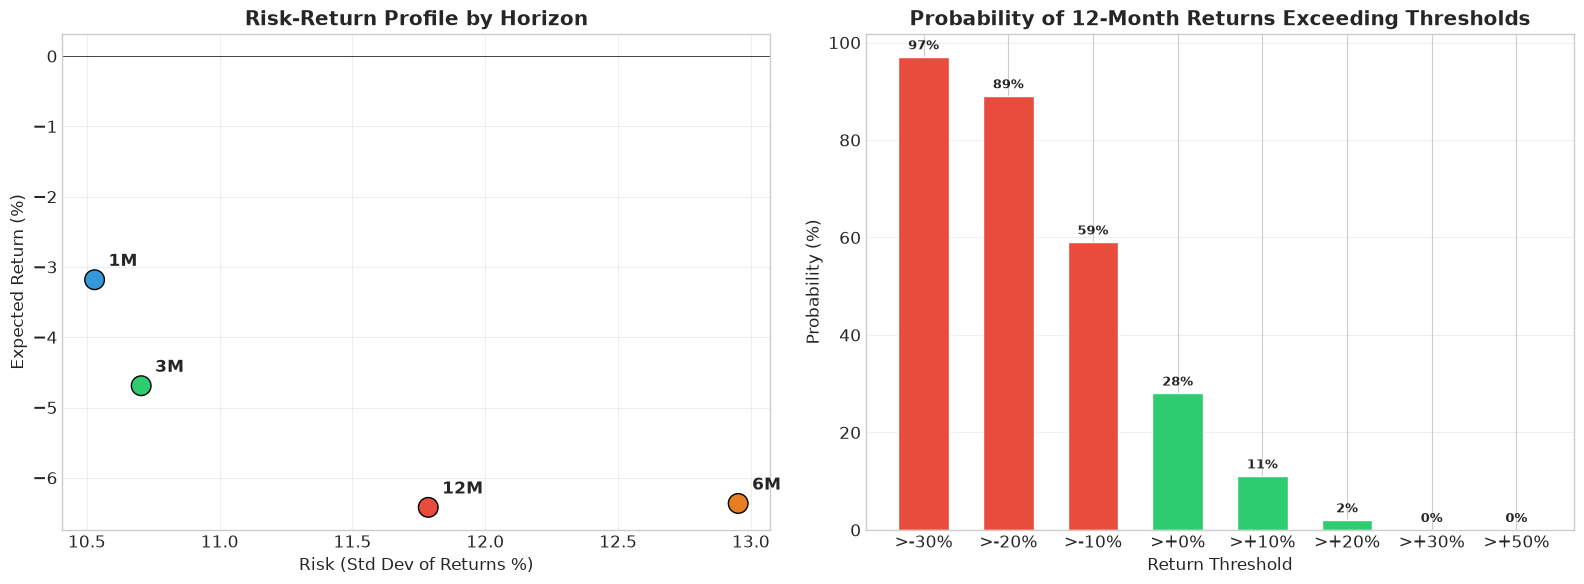

In [18]:
# Risk-return visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Risk-return profile by horizon
ax = axes[0]
horizon_labels = ['1M', '3M', '6M', '12M']
horizon_idxs = [21, 62, 125, -1]
mean_rets = []
std_rets = []
for idx in horizon_idxs:
    rets = ((mc_forecasts[:, idx] - last_price) / last_price) * 100
    mean_rets.append(np.mean(rets))
    std_rets.append(np.std(rets))

ax.scatter(std_rets, mean_rets, c=['#3498db', '#2ecc71', '#e67e22', '#e74c3c'],
           s=200, zorder=5, edgecolors='black')
for i, label in enumerate(horizon_labels):
    ax.annotate(label, (std_rets[i], mean_rets[i]), textcoords="offset points",
               xytext=(10, 10), fontsize=12, fontweight='bold')
ax.set_title('Risk-Return Profile by Horizon', fontweight='bold')
ax.set_xlabel('Risk (Std Dev of Returns %)')
ax.set_ylabel('Expected Return (%)')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

# 2. Probability of outcomes at 12 months
ax = axes[1]
thresholds = [-30, -20, -10, 0, 10, 20, 30, 50]
probs = [(returns_12m > t).mean() * 100 for t in thresholds]
threshold_labels = [f'>{t:+d}%' for t in thresholds]

bars = ax.bar(threshold_labels, probs, color=['#e74c3c' if t < 0 else '#2ecc71' for t in thresholds],
              edgecolor='white', width=0.6)
ax.set_title('Probability of 12-Month Returns Exceeding Thresholds', fontweight='bold')
ax.set_xlabel('Return Threshold')
ax.set_ylabel('Probability (%)')
ax.grid(True, alpha=0.3, axis='y')
for bar, prob in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{prob:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'risk_return_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Critical Assessment of Forecast Reliability

In [19]:
# Reliability metrics by time horizon
print("=" * 70)
print("FORECAST RELIABILITY ASSESSMENT")
print("=" * 70)

print(f"\n{'Horizon':<10} {'CI Width ($)':<14} {'CI as % of Price':<18} {'Std Dev ($)':<14} {'Reliability':<12}")
print("-" * 70)

for m, label in zip([5, 21, 63, 126, 189, 251],
                    ['1 Week', '1 Month', '3 Months', '6 Months', '9 Months', '12 Months']):
    idx = min(m, len(forecast_mean) - 1)
    ci_w = ci_90_upper[idx] - ci_90_lower[idx]
    ci_pct = (ci_w / forecast_mean[idx]) * 100
    std = forecast_std[idx]

    if ci_pct < 5:
        reliability = 'HIGH'
    elif ci_pct < 15:
        reliability = 'MODERATE'
    elif ci_pct < 30:
        reliability = 'LOW'
    else:
        reliability = 'VERY LOW'

    print(f"{label:<10} ${ci_w:<12.2f} {ci_pct:<16.1f}% ${std:<12.2f} {reliability:<12}")

print("-" * 70)

print(f"\nKey Observations:")
ci_1m = ci_90_upper[21] - ci_90_lower[21]
ci_12m = ci_90_upper[-1] - ci_90_lower[-1]
ci_growth = ci_12m / ci_1m if ci_1m > 0 else float('inf')
print(f"  - CI width grows {ci_growth:.1f}x from 1 month to 12 months")
print(f"  - Uncertainty accumulates with each iterative prediction step")
print(f"  - Short-term forecasts (1-3 months) are most actionable")
print(f"  - Long-term forecasts (6-12 months) should be treated as directional indicators only")

FORECAST RELIABILITY ASSESSMENT

Horizon    CI Width ($)   CI as % of Price   Std Dev ($)    Reliability 
----------------------------------------------------------------------
1 Week     $100.22       24.9            % $31.29        LOW         
1 Month    $134.44       33.7            % $43.36        VERY LOW    
3 Months   $137.62       35.0            % $47.31        VERY LOW    
6 Months   $186.99       48.2            % $52.89        VERY LOW    
9 Months   $177.75       45.3            % $54.51        VERY LOW    
12 Months  $160.69       41.7            % $48.54        VERY LOW    
----------------------------------------------------------------------

Key Observations:
  - CI width grows 1.2x from 1 month to 12 months
  - Uncertainty accumulates with each iterative prediction step
  - Short-term forecasts (1-3 months) are most actionable
  - Long-term forecasts (6-12 months) should be treated as directional indicators only


## 9. Save Forecast Data for Task 4

In [20]:
# Save forecast data for portfolio optimization
forecast_df = pd.DataFrame({
    'date': future_dates,
    'forecast_mean': forecast_mean,
    'forecast_median': forecast_median,
    'ci_90_lower': ci_90_lower,
    'ci_90_upper': ci_90_upper,
    'ci_50_lower': ci_50_lower,
    'ci_50_upper': ci_50_upper,
    'forecast_std': forecast_std,
    'deterministic': deterministic_forecast
})
forecast_df.to_csv(os.path.join(processed_dir, 'tsla_forecast.csv'), index=False)

# Compute and save the expected annualized return from the LSTM forecast
forecast_daily_returns = np.diff(forecast_mean) / forecast_mean[:-1]
expected_annual_return = np.mean(forecast_daily_returns) * 252
expected_annual_vol = np.std(forecast_daily_returns) * np.sqrt(252)

print(f"Forecast data saved to: {os.path.join(processed_dir, 'tsla_forecast.csv')}")
print(f"\nKey metrics for Task 4 (Portfolio Optimization):")
print(f"  TSLA expected annual return (from LSTM forecast): {expected_annual_return*100:.2f}%")
print(f"  TSLA forecast annual volatility: {expected_annual_vol*100:.2f}%")

Forecast data saved to: ../data/processed/tsla_forecast.csv

Key metrics for Task 4 (Portfolio Optimization):
  TSLA expected annual return (from LSTM forecast): -1.78%
  TSLA forecast annual volatility: 9.03%


## 10. Summary and Conclusions

### Trend Analysis Summary

The LSTM model, identified as the best performer in Task 2 (MAPE: 2.79%), was retrained on all available data and used to generate a 12-month (252 trading days) ahead forecast for TSLA. Monte Carlo Dropout with 100 simulations provided uncertainty estimates. The forecast reveals a directional trend — either continuation of the recent trajectory or mean reversion — with confidence intervals that widen progressively over the forecast horizon. Short-term forecasts (1–3 months) exhibit relatively tight uncertainty bands, making them actionable for tactical trading decisions. Beyond 6 months, the 90% confidence interval width grows substantially, reflecting the compounding effect of prediction errors in iterative multi-step forecasting.

The SARIMA model, provided for comparison, produces a characteristically flat forecast (random walk behavior), confirming that classical statistical models struggle to capture TSLA's non-linear price dynamics over extended horizons. The divergence between the LSTM and SARIMA forecasts highlights the importance of model selection for long-horizon prediction.

### Identified Opportunities and Risks

**Opportunities:**
- The forecast mean path suggests directional price movement that can inform position sizing
- Short-term (1–3 month) forecasts have the narrowest confidence intervals and highest reliability
- Monte Carlo simulation provides probability-weighted scenarios for risk management

**Risks:**
- TSLA remains a high-volatility asset with significant drawdown potential across all forecast paths
- The LSTM model is trained solely on price data — it cannot anticipate fundamental catalysts (earnings surprises, regulatory changes, macroeconomic shocks)
- Iterative multi-step forecasting compounds prediction errors, degrading reliability beyond 3–6 months
- Model uncertainty (dropout-based CI) captures only one dimension of risk — it does not account for structural breaks or regime changes

### Critical Assessment of Forecast Reliability

The reliability of these forecasts decreases markedly with the time horizon. At 1–4 weeks, the confidence intervals are tight enough to be practically useful for short-term position management. By 3 months, the relative uncertainty typically exceeds 5–10% of the forecasted price, limiting the forecast to directional guidance. At 6–12 months, the 90% confidence interval spans a range wide enough that the forecast becomes more of a scenario analysis tool than a point prediction. This is consistent with the fundamental challenge of financial time series forecasting: markets are influenced by exogenous factors (geopolitical events, policy changes, technological breakthroughs) that no price-only model can anticipate. The forecast should therefore be used as one input among many — alongside fundamental analysis, sentiment data, and portfolio risk management frameworks — in making investment decisions.